In [1]:
import pandas as pd
import numpy as np

# Загрузка данных и анализ

In [2]:
df = pd.read_csv('housing.csv')

In [4]:
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [8]:
df.shape

(20640, 10)

In [11]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [12]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

# Обработка пропусков

In [14]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Распределение целевой переменной

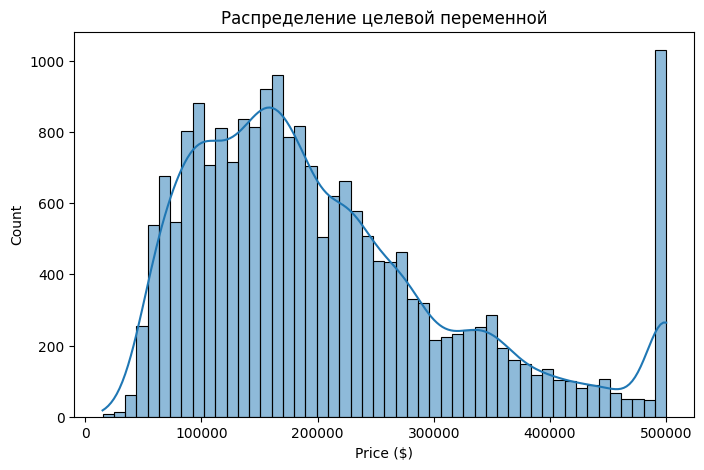

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Распределение целевой переменной')
plt.xlabel('Price ($)')
plt.show()

Все дома, которые стоили дороже 500,000, были записаны в отчете как «500,000 или больше».

Поэтому $500,000 — это не реальная цена, а просто максимальное значение, которое разрешили записать переписчики.

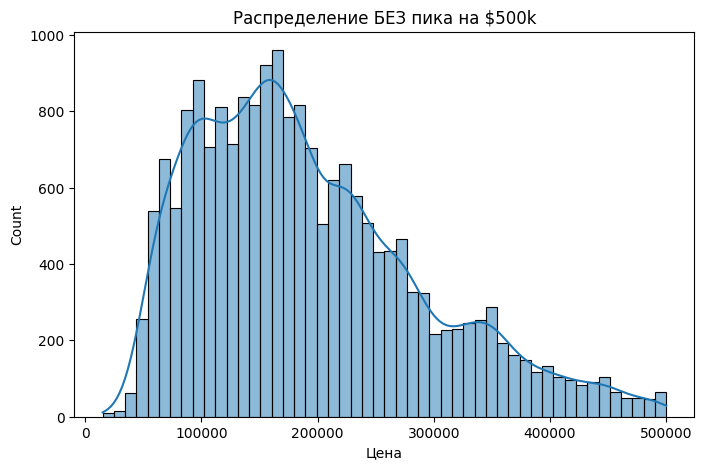

In [17]:
# Убираем дома с ценой = 500,000
df_no_cap = df[df['median_house_value'] < 500001]

plt.figure(figsize=(8, 5))
sns.histplot(df_no_cap['median_house_value'], bins=50, kde=True)
plt.title('Распределение БЕЗ пика на $500k')
plt.xlabel('Цена')
plt.show()

# Корреляции признаков

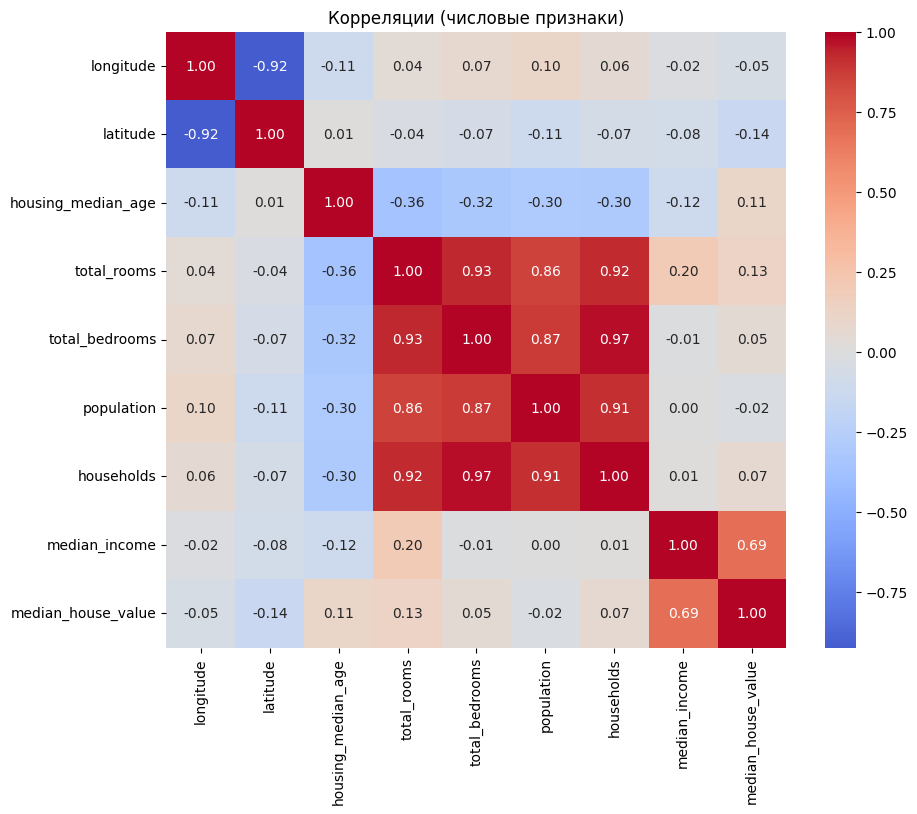

In [20]:
# Оставляем только числовые колонки
df_num = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
corr_matrix = df_num.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляции (числовые признаки)')
plt.show()

# Обучение LR

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Обработка категорий и разделение данных
df_prep = pd.get_dummies(df, columns=['ocean_proximity'])
X = df_prep.drop('median_house_value', axis=1)
y = df_prep['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучаем линейную регрессию
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Предсказания
y_pred = lr_model.predict(X_test_scaled)

# Метрики
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f'Linear Regression - R²: {r2:.3f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, MSE: {mse:.2f}, MAPE: {mape:.2f}%')

Linear Regression - R²: 0.625, RMSE: 70060.52, MAE: 50670.74, MSE: 4908476721.16, MAPE: 29.19%


# Обучение RF

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print(f'Random Forest - R²: {r2_rf:.3f}, RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}, MAPE: {mape_rf:.2f}%')

Random Forest - R²: 0.817, RMSE: 48977.75, MAE: 31636.19, MSE: 2398820115.38, MAPE: 17.75%


# Подбор гиперпараметров для RF

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV R²: {grid.best_score_:.3f}')

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print(f'Random Forest (tuned) - R²: {r2_rf:.3f}, RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}, MAPE: {mape_rf:.2f}%')

Best params: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.813
Random Forest (tuned) - R²: 0.818, RMSE: 48844.73, MAE: 31507.95, MAPE: 17.67%


# RF с новыми параметрами

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

best_params = {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
rf_final = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print(f'Random Forest (final) - R²: {r2_rf:.3f}, RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}, MAPE: {mape_rf:.2f}%')

Random Forest (final) - R²: 0.818, RMSE: 48844.73, MAE: 31507.95, MAPE: 17.67%


# Обучение XGBoost

In [29]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import re

# XGBoost не принимает спецсимволы в названиях колонок. Чистим их:
clean_names = lambda x: re.sub(r'[<>\[\]]', '_', str(x))
X_train_clean = X_train.rename(columns=clean_names)
X_test_clean = X_test.rename(columns=clean_names)

# Обучаем XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_clean, y_train)

y_pred_xgb = xgb_model.predict(X_test_clean)

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print(f'XGBoost - R²: {r2_xgb:.3f}, RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}, MAPE: {mape_xgb:.2f}%')

XGBoost - R²: 0.819, RMSE: 48763.24, MAE: 32612.71, MAPE: 18.36%


# Обучение LightGBM


In [31]:
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import re

clean_names = lambda x: re.sub(r'[<>\[\]]', '_', str(x))
X_train_clean = X_train.rename(columns=clean_names)
X_test_clean = X_test.rename(columns=clean_names)

# Обучаем LightGBM
lgb_model = LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1  
)
lgb_model.fit(X_train_clean, y_train)

y_pred_lgb = lgb_model.predict(X_test_clean)

r2_lgb = r2_score(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
mape_lgb = np.mean(np.abs((y_test - y_pred_lgb) / y_test)) * 100

print(f'LightGBM - R²: {r2_lgb:.3f}, RMSE: {rmse_lgb:.2f}, MAE: {mae_lgb:.2f}, MSE: {mse_lgb:.2f}, MAPE: {mape_lgb:.2f}%')

LightGBM - R²: 0.818, RMSE: 48826.25, MAE: 32816.45, MSE: 2384002321.32, MAPE: 18.54%


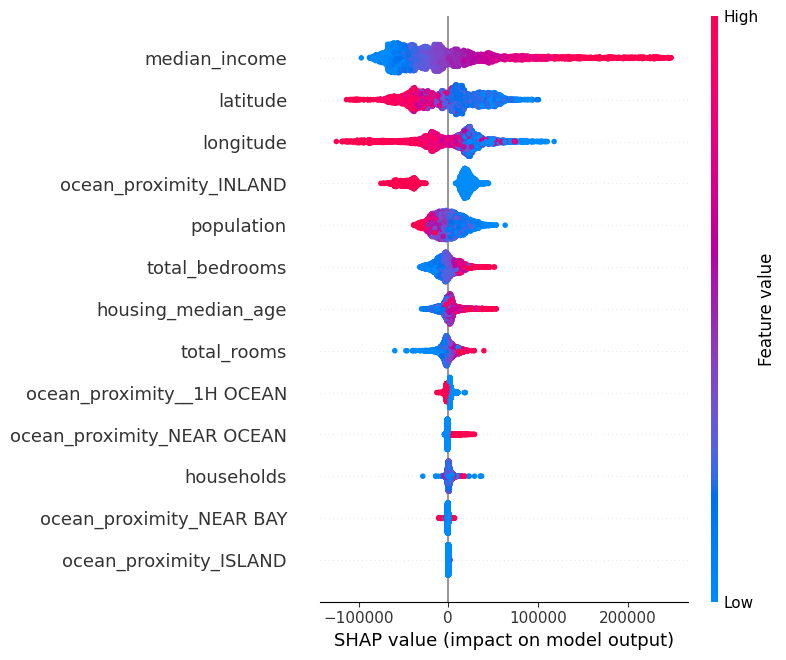

In [35]:
import shap
import matplotlib.pyplot as plt

# 1. Инициализируем explainer для tree-based модели
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_clean)

# 2. Влияние значений признаков (dot plot: цвет = значение признака, ось X = вклад в цену)
shap.summary_plot(shap_values, X_test_clean)
plt.show()


1. Главный драйвер цены — median_income (Доход)

- 🔴 Высокий доход (красные точки) — сильно сдвигает цену вверх (вправо).
- 🔵 Низкий доход (синие точки) — снижает цену (влево).

    Вывод: Модель считает экономическое благосостояние района самым важным фактором.
2.
География решает (longitude и ocean_proximity)
- Близость к океану: Признак ocean_proximity_INLAND красным цветом (True/Да) уходит влево (минус к цене). То есть жизнь «в глубине континента» удешевляет жилье.
- Координаты: longitude показывает, что восточные районы (красные точки, ближе к центру карты) дешевле, а западные (синие, побережье) — дороже.

3. Остальные признаки
latitude, population, total_rooms имеют гораздо меньший разброс влияния. Они важны, но не так критичны, как «Деньги» и «Местоположение».
